In [78]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import superlets_package.morlet as morlet
import superlets_package.superlets as superlet
import jax.numpy as jnp

import superlets_package.superlet as superlet_new
import superlets_package.auxiliar_functions as aux
import superlets_package.cwt as cwt_new
import os

In [79]:
importlib.reload(superlet_new)

<module 'superlets_package.superlet' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/superlet.py'>

In [80]:
importlib.reload(cwt_new)

<module 'superlets_package.cwt' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/cwt.py'>

In [81]:
importlib.reload(aux)

<module 'superlets_package.auxiliar_functions' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/auxiliar_functions.py'>

In [82]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

In [83]:
fs = 1024
signal_duration = 3
t = np.linspace(0, signal_duration, signal_duration * fs)

np.random.seed(10)
noise = np.random.normal(0, 0.01, len(t))

burst_duration = 0.5
burst_start = 1
real_t_onset = burst_start
real_t_offset = burst_start + burst_duration

start_idx = np.searchsorted(t, burst_start)
end_idx = np.searchsorted(t, burst_start + burst_duration)

MNF ideal = 149.14318138165422
MNF analytic = 164.77343195705885


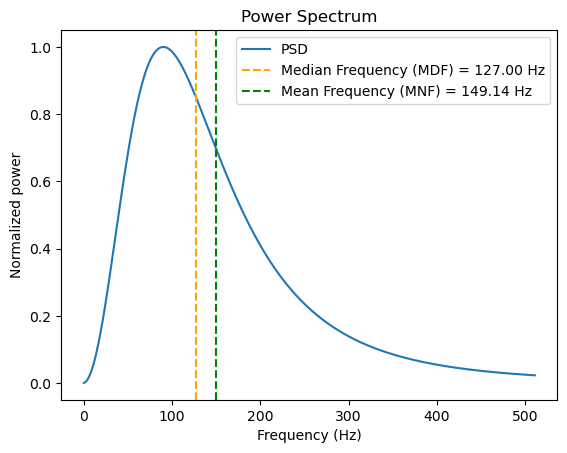

In [117]:
burst = []
[filtro, PdeLuca, burst, MNF_ideal, MNF_analytic] = aux.fdeluca(140, 110, fs, burst_duration, plot = False)
print(f'MNF ideal = {MNF_ideal}')
print(f'MNF analytic = {MNF_analytic}')
MNF_1 = [MNF_ideal]

In [118]:
folder_out = f'/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/NEW_SLT/SIMULATED_EMG/{burst_duration}_S'
new_folder_path = os.path.join(folder_out, str(round(MNF_1[0], 2)) + ' Hz')
os.makedirs(new_folder_path, exist_ok=True)

In [119]:
filename = os.path.join(new_folder_path, str(round(MNF_1[0], 2)) + ' Hz.npy')

if os.path.exists(filename):
    burst_signal = np.load(filename)
else:
    burst_signal = noise.copy()
    burst_signal[int(burst_start * fs):int(burst_start * fs + len(burst))] = burst
    
    np.save(filename, burst_signal)

In [120]:
save = False

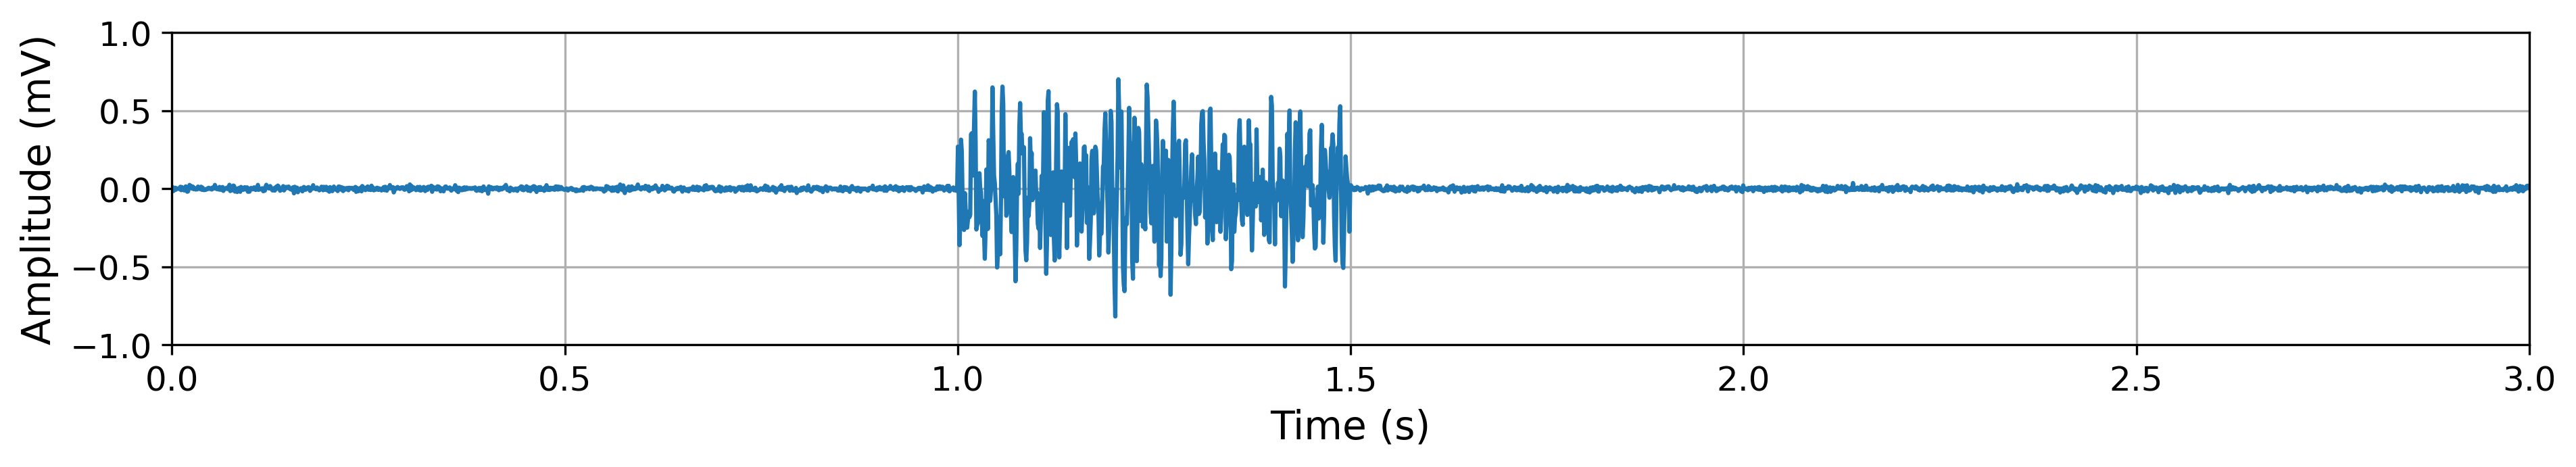

In [121]:
fig, ax = plt.subplots(figsize=(15, 2), dpi=300)
ax.set_xlabel("Time (s)", fontsize=fontsize_labels)
ax.set_ylabel("Amplitude (mV)", fontsize=fontsize_labels)
ax.set_xlim(0,3)
ax.set_ylim(-1,1)

ax.plot(np.linspace(0, len(burst_signal)/fs, len(burst_signal)), burst_signal)

ax.tick_params(axis='both', labelsize=fontsize_ticks)
ax.grid(True)

if save:
    fig.savefig(os.path.join(new_folder_path,"emg.png"), dpi=300, bbox_inches="tight")
    

In [122]:
freqs = np.linspace(10,500,int(fs/2))

In [106]:
# SNR = 15
# # if 'SNR' not in globals():
# #     SNR = "Inf"
# signal_15, xn = aux.add_noise(burst_signal, SNR, fs, plot = True)
# real_snr = aux.compute_snr(signal_15, xn)
# print(f'{real_snr} dB')

# Define the space of the parameters

In [107]:
w_f = 1
w_t = 1
eps = 1e-12

# CWT

In [92]:
params_cwt = np.arange(1, 302, 10)

heatmap_f = np.zeros(len(params_cwt))
heatmap_t = np.zeros(len(params_cwt))
heatmap_total = np.zeros(len(params_cwt))

print("\n==========================================================")
print("        OUR CWT → Barrido 1D parámetro c")
print("==========================================================\n")

for i, c in enumerate(params_cwt):
    print(f"Checking parameter c = {c}")

    # try:
    wavelet = f'cmor{c}-1.0'

    # Transformada CWT
    cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(burst_signal, wavelet, freqs, fs)

    scalogram = np.abs(cwtmatr)**2

    # --- Instant freq ---
    instant_freq = np.sum(scalogram * f[:, None], axis=0) / (np.sum(scalogram, axis=0) + 1e-12)
    instant_freq_burst = instant_freq[start_idx:end_idx]
    mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

    # --- Onset/offset ---
    t_on, t_off = aux.get_onset_offset(
        scalogram,
        burst_start,
        burst_duration,
        t,
        fs,
        plot_results=False
    )
    mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

    # Métrica total ponderada
    total = w_f * mae_f + w_t * mae_t

    # except Exception as e:
    #     print(f"ERROR parámetro c={c}: {e}")
    #     mae_f = mae_t = total = np.nan

    heatmap_f[i] = mae_f
    heatmap_t[i] = mae_t
    heatmap_total[i] = total

# -----------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

ax1.plot(params_cwt, heatmap_f, marker='x', linestyle='--')
ax1.set_title('Error en frecuencia')
ax1.set_ylabel('MAE (Hz)')
ax1.grid(True)

ax2.plot(params_cwt, heatmap_t, marker='s', linestyle='--')
ax2.set_title('Error en tiempo')
ax2.set_ylabel('MAE (s)')
ax2.grid(True)

for ax in (ax1, ax2):
    ax.set_xlabel('Parámetro c (Our CWT)')

fig.suptitle('Barrido del parámetro c – Our CWT')
fig.tight_layout()
plt.show()


# -----------------------------------------------------------
# Localizar mínimo
idx_min = np.nanargmin(heatmap_total)
best_c = params_cwt[idx_min]

print("\n==========================================================")
print("MÍNIMO 1D → parámetro c (Our CWT)")
print("==========================================================")
print(f"Mejor parámetro c = {best_c}")
print(f"Error mínimo total = {heatmap_total[idx_min]:.4f}")
print(f"Error mínimo frecuencia = {heatmap_f[idx_min]:.4f}")
print(f"Error mínimo tiempo = {heatmap_t[idx_min]:.4f}")



        OUR CWT → Barrido 1D parámetro c

Checking parameter c = 1
Checking parameter c = 11
Checking parameter c = 21
Checking parameter c = 31
Checking parameter c = 41
Checking parameter c = 51
Checking parameter c = 61
Checking parameter c = 71
Checking parameter c = 81
Checking parameter c = 91
Checking parameter c = 101
Checking parameter c = 111
Checking parameter c = 121
Checking parameter c = 131
Checking parameter c = 141
Checking parameter c = 151
Checking parameter c = 161
Checking parameter c = 171
Checking parameter c = 181
Checking parameter c = 191


KeyboardInterrupt: 

# Superlet Transform


             SUPERLET → Barrido COMPLETO 3D


===== baseCycle = 1 =====
Checking min order = 1
Checking max order = 2
Checking max order = 7
Checking max order = 12
Checking max order = 17
Checking max order = 22
Checking max order = 27
Checking max order = 32
Checking max order = 37
Checking max order = 42
Checking max order = 47
Checking min order = 6
Checking max order = 2
Checking max order = 7
Checking max order = 12
Checking max order = 17
Checking max order = 22
Checking max order = 27
Checking max order = 32
Checking max order = 37
Checking max order = 42
Checking max order = 47
Checking min order = 11
Checking max order = 2
Checking max order = 7
Checking max order = 12
Checking max order = 17
Checking max order = 22
Checking max order = 27
Checking max order = 32
Checking max order = 37
Checking max order = 42
Checking max order = 47

===== baseCycle = 6 =====
Checking min order = 1
Checking max order = 2
Checking max order = 7
Checking max order = 12
Checking max order = 17

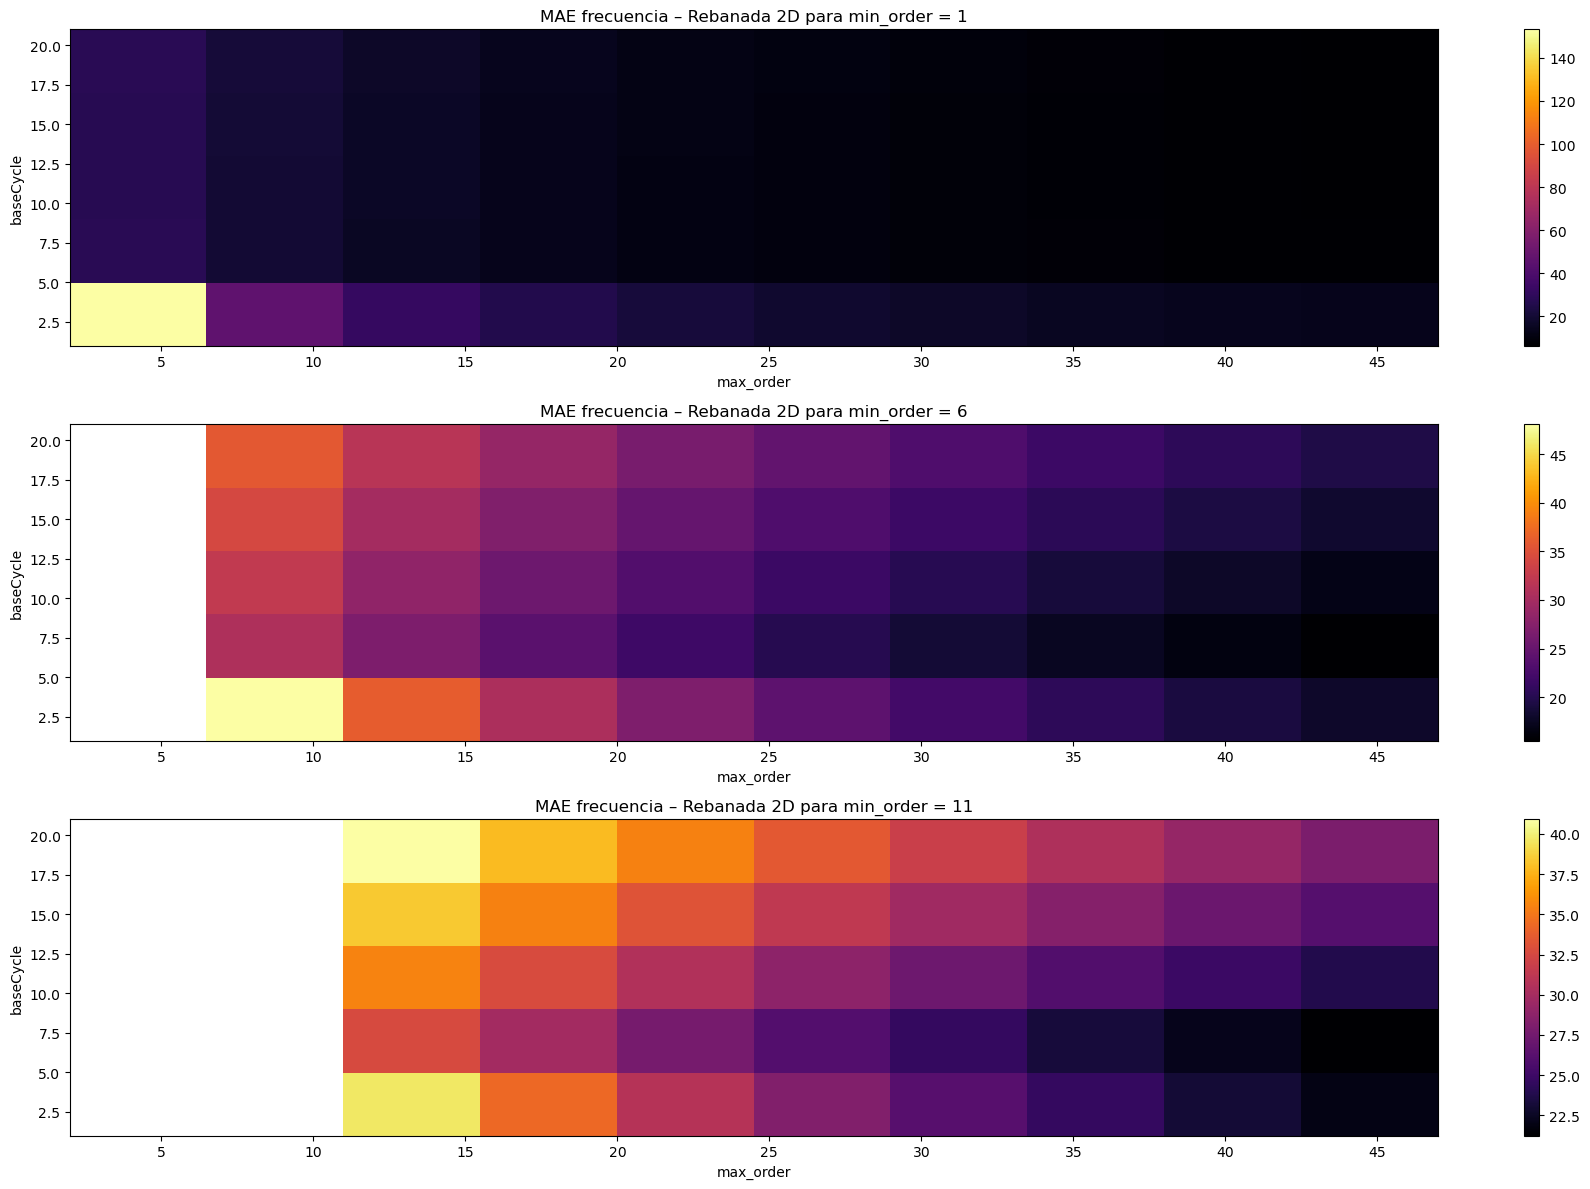

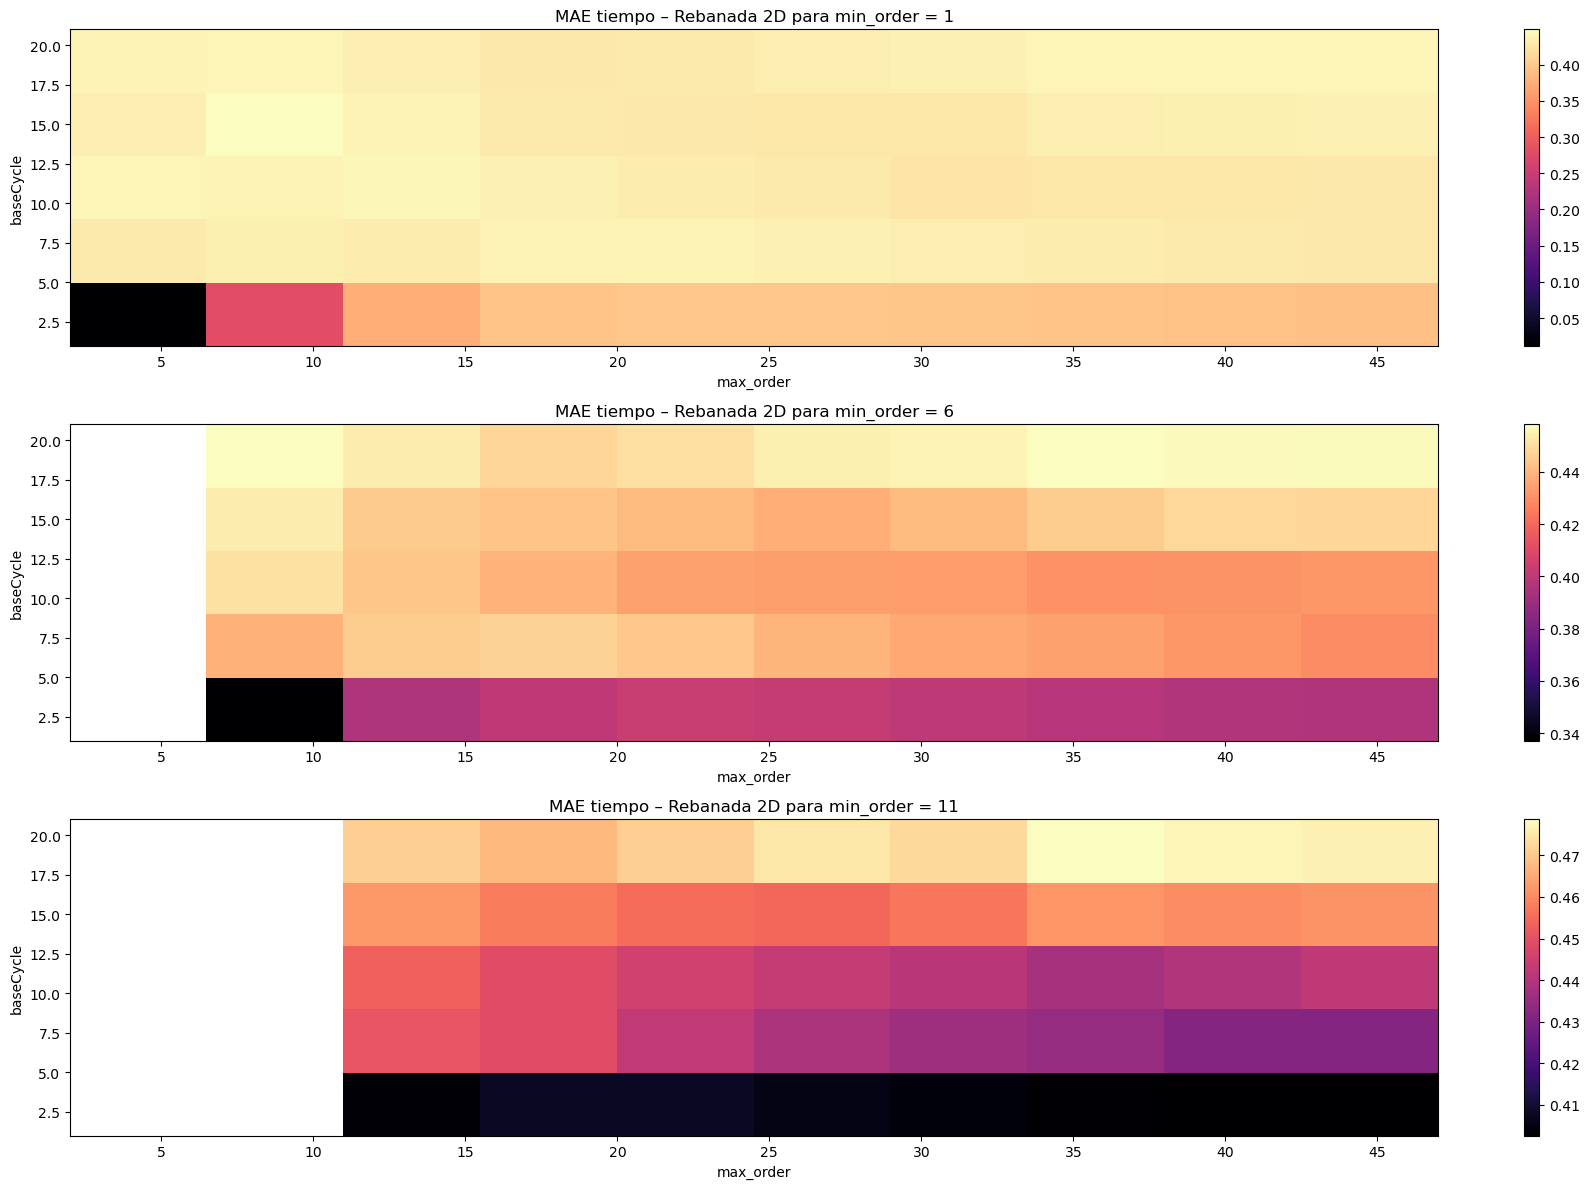

In [38]:
# ============================================================
#                 DEFINICIÓN DE PARRILLA 3D
# ============================================================

bases_3d = np.arange(1, 22, 5)          # eje baseCycle
min_orders_3d = np.arange(1, 12, 5)      # eje min_order
max_orders_3d = np.arange(2, 48, 5)    # eje max_order

heatmap_3d   = np.zeros((len(bases_3d), len(min_orders_3d), len(max_orders_3d)))
heatmap_f_3d = np.zeros((len(bases_3d), len(min_orders_3d), len(max_orders_3d)))
heatmap_t_3d = np.zeros((len(bases_3d), len(min_orders_3d), len(max_orders_3d)))

eps = 1e-12

print("\n==========================================================")
print("             SUPERLET → Barrido COMPLETO 3D")
print("==========================================================\n")

for i, base in enumerate(bases_3d):
    print(f"\n===== baseCycle = {base} =====")

    for k, o_min in enumerate(min_orders_3d):
        print(f'Checking min order = {o_min}')

        for j, o_max in enumerate(max_orders_3d):
            print(f'Checking max order = {o_max}')

            # Evitar max_order < min_order
            if o_max <= o_min:
                heatmap_3d[i, k, j]   = np.nan
                heatmap_f_3d[i, k, j] = np.nan
                heatmap_t_3d[i, k, j] = np.nan
                continue

            # try:
            scalogram_slt = superlet_new.superlets(burst_signal, fs, freqs,base, [o_min, o_max])

            # scalogram_slt = np.abs(out) ** 2
            
            instant_freq = np.sum(
                scalogram_slt * freqs[:, None], axis=0
            ) / (np.sum(scalogram_slt, axis=0) + eps)

            instant_freq_burst = instant_freq[start_idx:end_idx]
            
            mae_f, _ = aux.calculate_mae(instant_freq_burst, MNF_1[0])

            # ========== Onset-offset ==========
            t_on, t_off = aux.get_onset_offset(
                scalogram_slt,
                burst_start,
                burst_duration,
                t,
                fs,
                plot_results=False
            )
            mae_t, _ = superlet.calculate_mae(
                (t_on, t_off),
                (real_t_onset, real_t_offset)
            )

            # ----------- Guardar errores separados -----------
            heatmap_f_3d[i, k, j] = mae_f
            heatmap_t_3d[i, k, j] = mae_t

            # ===== Métrica total =====
            total = w_f * mae_f + w_t * mae_t

            # except Exception as e:
            #     print(f"ERROR base={base}, min={o_min}, max={o_max}: {e}")
            # 
            #     heatmap_3d[i, k, j]   = np.nan
            #     heatmap_f_3d[i, k, j] = np.nan
            #     heatmap_t_3d[i, k, j] = np.nan
            #     continue

            heatmap_3d[i, k, j] = total

# ============================================================
# ============== LOCALIZAR MÍNIMO GLOBAL 3D ==================
# ============================================================

idx = np.nanargmin(heatmap_3d)
best_i, best_k, best_j = np.unravel_index(idx, heatmap_3d.shape)

best_base = bases_3d[best_i]
best_min  = min_orders_3d[best_k]
best_max  = max_orders_3d[best_j]

print("\n==========================================================")
print("                 MÍNIMO GLOBAL 3D")
print("==========================================================")
print(f"Mejor baseCycle = {best_base}")
print(f"Mejor min_order = {best_min}")
print(f"Mejor max_order = {best_max}")
print(f"Error mínimo    = {heatmap_3d[best_i, best_k, best_j]:.4f}")

# ============================================================
# ===================== REBANADAS 2D =========================
# ============================================================

# ------------------------------------------------------------
# Rebanadas – Error en FRECUENCIA
# ------------------------------------------------------------
plt.figure(figsize=(18, 4 * len(min_orders_3d)))

for k, o_min in enumerate(min_orders_3d):

    slice_f = heatmap_f_3d[:, k, :]

    ax = plt.subplot(len(min_orders_3d), 1, k + 1)

    im = ax.imshow(
        slice_f,
        origin="lower",
        cmap="inferno",
        aspect="auto",
        extent=[max_orders_3d[0], max_orders_3d[-1],
                bases_3d[0], bases_3d[-1]]
    )

    ax.set_title(f"MAE frecuencia – Rebanada 2D para min_order = {o_min}")
    ax.set_xlabel("max_order")
    ax.set_ylabel("baseCycle")

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Rebanadas – Error en TIEMPO
# ------------------------------------------------------------
plt.figure(figsize=(18, 4 * len(min_orders_3d)))

for k, o_min in enumerate(min_orders_3d):

    slice_t = heatmap_t_3d[:, k, :]

    ax = plt.subplot(len(min_orders_3d), 1, k + 1)

    im = ax.imshow(
        slice_t,
        origin="lower",
        cmap="magma",
        aspect="auto",
        extent=[max_orders_3d[0], max_orders_3d[-1],
                bases_3d[0], bases_3d[-1]]
    )

    ax.set_title(f"MAE tiempo – Rebanada 2D para min_order = {o_min}")
    ax.set_xlabel("max_order")
    ax.set_ylabel("baseCycle")

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()




# STFT

In [39]:
nfft = 2 * (len(freqs))

In [40]:
nfft

1024

In [45]:
from scipy.signal import stft, windows



        STFT → Barrido 1D parámetro W

Checking parameter w = 2
Checking parameter w = 12
Checking parameter w = 22
Checking parameter w = 32
Checking parameter w = 42
Checking parameter w = 52
Checking parameter w = 62
Checking parameter w = 72
Checking parameter w = 82
Checking parameter w = 92
Checking parameter w = 102
Checking parameter w = 112
Checking parameter w = 122
Checking parameter w = 132
Checking parameter w = 142
Checking parameter w = 152
Checking parameter w = 162
Checking parameter w = 172
Checking parameter w = 182
Checking parameter w = 192
Checking parameter w = 202
Checking parameter w = 212
Checking parameter w = 222
Checking parameter w = 232
Checking parameter w = 242
Checking parameter w = 252
Checking parameter w = 262
Checking parameter w = 272
Checking parameter w = 282
Checking parameter w = 292


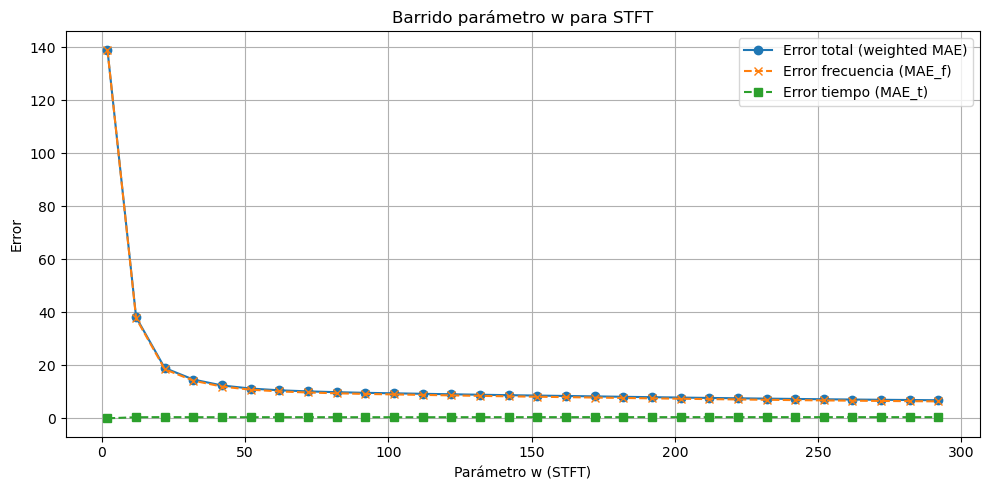


MÍNIMO 1D → parámetro w (STFT)
Mejor parámetro c = 292
Error mínimo total = 6.8258
Error mínimo frecuencia = 6.3903
Error mínimo tiempo = 0.4355


In [41]:
params_cwt = np.arange(2, 302, 10)

heatmap_f = np.zeros(len(params_cwt))
heatmap_t = np.zeros(len(params_cwt))
heatmap_total = np.zeros(len(params_cwt))

print("\n==========================================================")
print("        STFT → Barrido 1D parámetro W")
print("==========================================================\n")

for i, c in enumerate(params_cwt):
    print(f"Checking parameter w = {c}")

    try:
        window = windows.blackman(c)

        f, t_stft, Zxx = stft(
            burst_signal, fs=fs, window=window, nperseg=c, noverlap=c-1, nfft=nfft,
            detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum'
        )

        Zxx_power = np.abs(Zxx) ** 2
        scalogram = Zxx_power
    

        # --- Instant freq ---
        instant_freq = np.sum(scalogram * f[:, None], axis=0) / (np.sum(scalogram, axis=0) + eps)
        instant_freq_burst = instant_freq[start_idx:end_idx]
        mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

        first_indices = []
        last_indices = []
        
        for row in scalogram:
            first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t_stft, fs, plot_results = False)
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t_stft[first_indices]
        t_offset = t_stft[last_indices]
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

        # Métrica total ponderada
        total = w_f * mae_f + w_t * mae_t

    except Exception as e:
        print(f"ERROR parámetro c={c}: {e}")
        mae_f = mae_t = total = np.nan

    heatmap_f[i] = mae_f
    heatmap_t[i] = mae_t
    heatmap_total[i] = total

# -----------------------------------------------------------
# Graficar heatmap (en 1D solo curva)
plt.figure(figsize=(10, 5))
plt.plot(params_cwt, heatmap_total, marker='o', label='Error total (weighted MAE)')
plt.plot(params_cwt, heatmap_f, marker='x', linestyle='--', label='Error frecuencia (MAE_f)')
plt.plot(params_cwt, heatmap_t, marker='s', linestyle='--', label='Error tiempo (MAE_t)')

plt.xlabel('Parámetro w (STFT)')
plt.ylabel('Error')
plt.title('Barrido parámetro w para STFT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Localizar mínimo
idx_min = np.nanargmin(heatmap_total)
best_c = params_cwt[idx_min]

print("\n==========================================================")
print("MÍNIMO 1D → parámetro w (STFT)")
print("==========================================================")
print(f"Mejor parámetro c = {best_c}")
print(f"Error mínimo total = {heatmap_total[idx_min]:.4f}")
print(f"Error mínimo frecuencia = {heatmap_f[idx_min]:.4f}")
print(f"Error mínimo tiempo = {heatmap_t[idx_min]:.4f}")


# BAYESIAN OPTIMIZATION

In [123]:
import optuna

def objective_our_cwt(trial):
    seed = trial.number  # Semilla única por prueba
    np.random.seed(seed)
    
    # Optimizar número de ciclos de la wavelet entre 1 y 100
    c = trial.suggest_int('num_cycles', 1, 300)
    wavelet = f'cmor{c}-1.0'

    try:
        # Transformada CWT
        cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(burst_signal, wavelet, freqs, fs)

        # Escalograma al cuadrado
        scalogram_2 = np.array(jnp.abs(cwtmatr)**2)

        # Frecuencia instantánea promedio
        instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]
        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        
        # Energía total por tiempo
        t_on, t_off = aux.get_onset_offset(
            scalogram_2,
            burst_start,
            burst_duration,
            t,
            fs,
            plot_results=False
        )

        # MAE tiempo
        mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

        # print(f"[Trial {trial.number}] c={c} → MAE_f: {mae_f:.4f}, MAE_t: {mae_t:.4f}")

        return mae_f, mae_t

    except Exception as e:
        print(f"[Trial {trial.number}] ERROR: {e}")
        return float('inf'), float('inf')


study_our_cwt = optuna.create_study(directions=["minimize", "minimize"])
study_our_cwt.optimize(objective_our_cwt, n_trials=200)

[I 2026-01-20 12:49:24,876] A new study created in memory with name: no-name-684f5dd3-7788-4c48-82fe-4800b81c98cc
[I 2026-01-20 12:49:25,125] Trial 0 finished with values: [17.10894231945455, 0.02651410116818625] and parameters: {'num_cycles': 6}.
[I 2026-01-20 12:49:25,370] Trial 1 finished with values: [17.781707644015572, 0.02529300054949527] and parameters: {'num_cycles': 5}.
[I 2026-01-20 12:49:25,616] Trial 2 finished with values: [7.833658159631877, 0.04127733484614132] and parameters: {'num_cycles': 119}.
[I 2026-01-20 12:49:25,872] Trial 3 finished with values: [7.926351419013458, 0.041188296259361774] and parameters: {'num_cycles': 102}.
[I 2026-01-20 12:49:26,123] Trial 4 finished with values: [8.68951460756455, 0.04080574833116249] and parameters: {'num_cycles': 57}.
[I 2026-01-20 12:49:26,365] Trial 5 finished with values: [10.461025437942384, 0.03797304929176164] and parameters: {'num_cycles': 30}.
[I 2026-01-20 12:49:26,608] Trial 6 finished with values: [7.6787735622250

In [124]:
seen = set()
unique_best = []

for trial in sorted(study_our_cwt.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    print(f"{i}. {params} → MAE_f = {trial.values[0]:.4f}, MAE_t = {trial.values[1]:.4f}")

best_weighted = min(study_our_cwt.trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):")
print(f"{best_weighted.params} → "
      f"MAE_f = {best_weighted.values[0]:.4f}, MAE_t = {best_weighted.values[1]:.4f}, "
      f"Score = {w_f * best_weighted.values[0] + w_t * best_weighted.values[1]:.4f}")

best_f = min(study_our_cwt.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"{best_f.params} → MAE_f = {best_f.values[0]:.4f}, MAE_t = {best_f.values[1]:.4f}")

best_t = min(study_our_cwt.trials, key=lambda x: x.values[1])
print("\n⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"{best_t.params} → MAE_f = {best_t.values[0]:.4f}, MAE_t = {best_t.values[1]:.4f}")


# --- Visualización del frente de Pareto ---
mae_f_vals_our_wavelet = [b.values[0] for b in study_our_cwt.trials]
mae_t_vals_our_wavelet = [b.values[1] for b in study_our_cwt.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. {'num_cycles': 298} → MAE_f = 7.6444, MAE_t = 0.0411
2. {'num_cycles': 294} → MAE_f = 7.6451, MAE_t = 0.0411
3. {'num_cycles': 293} → MAE_f = 7.6453, MAE_t = 0.0411

🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):
{'num_cycles': 298} → MAE_f = 7.6444, MAE_t = 0.0411, Score = 7.6855

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
{'num_cycles': 298} → MAE_f = 7.6444, MAE_t = 0.0411

⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):
{'num_cycles': 3} → MAE_f = 19.5885, MAE_t = 0.0217


# Superlet Transform

In [125]:
def objective_superlet(trial):
    seed = trial.number  # Semilla única por prueba
    np.random.seed(seed)
    
#     bases_3d = np.arange(1, 22, 10)          # eje baseCycle
# min_orders_3d = np.arange(1, 12, 5)      # eje min_order
# max_orders_3d = np.arange(2, 53, 10)    # eje max_order
    
    base = trial.suggest_int('base_cycle', 5, 20)
    min_o = trial.suggest_int('min_order', 1, 2)
    max_o = trial.suggest_int('max_order', 20, 40)

    if min_o > max_o:
        return float('inf'), float('inf')

    try:
        scalogram = superlet_new.superlets(burst_signal, fs, freqs,base, [min_o, max_o])

        # scalogram_2 = np.abs(scalogram)**2
        instant_freq = np.sum(scalogram * freqs[:, np.newaxis], axis=0) / np.sum(scalogram, axis=0)
        
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        
        # ========== Onset-offset ==========
        t_on, t_off = aux.get_onset_offset(
            scalogram,
            burst_start,
            burst_duration,
            t,
            fs,
            plot_results=False
        )
        
        mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

        return mae_f, mae_t

    except Exception as e:
        return float('inf'), float('inf')

study_superlet = optuna.create_study(directions=["minimize", "minimize"])
study_superlet.optimize(objective_superlet, n_trials=200)

[I 2026-01-20 12:51:08,471] A new study created in memory with name: no-name-7391dcc1-ead6-4733-8df8-4d00f65289b3
[I 2026-01-20 12:51:10,084] Trial 0 finished with values: [9.752913107379308, 0.05460259534760664] and parameters: {'base_cycle': 7, 'min_order': 2, 'max_order': 35}.
[I 2026-01-20 12:51:12,052] Trial 1 finished with values: [4.521420717173128, 0.0679291278288831] and parameters: {'base_cycle': 17, 'min_order': 1, 'max_order': 39}.
[I 2026-01-20 12:51:13,553] Trial 2 finished with values: [10.031458308184543, 0.056551586413220445] and parameters: {'base_cycle': 9, 'min_order': 2, 'max_order': 32}.
[I 2026-01-20 12:51:15,351] Trial 3 finished with values: [9.522602941717484, 0.06706481754721588] and parameters: {'base_cycle': 16, 'min_order': 2, 'max_order': 35}.
[I 2026-01-20 12:51:16,723] Trial 4 finished with values: [6.980844620627628, 0.05797811177140996] and parameters: {'base_cycle': 10, 'min_order': 1, 'max_order': 31}.
[I 2026-01-20 12:51:18,402] Trial 5 finished wi

In [126]:
# Obtener los trials únicos de la frontera de Pareto, según combinación de parámetros
seen = set()
unique_best = []

for trial in sorted(study_superlet.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

# Imprimir configuraciones únicas del Pareto front
print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    mae_f, mae_t = trial.values
    print(f"{i}. base_cycle={params['base_cycle']}, min_order={params['min_order']}, max_order={params['max_order']} → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

# Obtener el mejor resultado único (mínima suma de errores)
# best = min(unique_best, key=lambda x: sum(x.values))
best = min(unique_best, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación única (f + t mínimas):")
print(f"base_cycle={best.params['base_cycle']}, min_order={best.params['min_order']}, max_order={best.params['max_order']}")
print(f"MAE_f={best.values[0]:.4f}, MAE_t={best.values[1]:.4f}")

# Obtener el trial con menor error solo en frecuencia (MAE_f)
best_f = min(study_superlet.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"base_cycle={best_f.params['base_cycle']}, min_order={best_f.params['min_order']}, max_order={best_f.params['max_order']}")
print(f"MAE_f={best_f.values[0]:.4f}, MAE_t={best_f.values[1]:.4f}")

# Obtener el trial con menor error solo en tiempo (MAE_t)
best_t = min(study_superlet.trials, key=lambda x: x.values[1])
print("\n⚡ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"base_cycle={best_t.params['base_cycle']}, min_order={best_t.params['min_order']}, max_order={best_t.params['max_order']}")
print(f"MAE_f={best_t.values[0]:.4f}, MAE_t={best_t.values[1]:.4f}")


# Visualización rápida del pareto front
mae_f_vals_superlet = [b.values[0] for b in study_superlet.trials]
mae_t_vals_superlet = [b.values[1] for b in study_superlet.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. base_cycle=14, min_order=1, max_order=40 → MAE_f=4.3312, MAE_t=0.0637
2. base_cycle=12, min_order=1, max_order=40 → MAE_f=4.5658, MAE_t=0.0613
3. base_cycle=11, min_order=1, max_order=39 → MAE_f=4.9443, MAE_t=0.0606

🎯 Mejor combinación única (f + t mínimas):
base_cycle=14, min_order=1, max_order=40
MAE_f=4.3312, MAE_t=0.0637

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
base_cycle=14, min_order=1, max_order=40
MAE_f=4.3312, MAE_t=0.0637

⚡ Mejor combinación solo en tiempo (mínimo MAE_t):
base_cycle=5, min_order=1, max_order=25
MAE_f=12.7844, MAE_t=0.0478


In [127]:
nfft = 2 * (len(freqs))
ms_per_cycle = 12.67

In [128]:
def objective_stft(trial):
    seed = trial.number
    np.random.seed(seed)
    
    num_cycles = trial.suggest_int('num_cycles', 2, 300)
    w = int(num_cycles * ms_per_cycle)

    # Evitar casos inválidos donde la ventana sea mayor que nfft fijo
    if w > nfft:
        return float('inf'), float('inf')

    try:
        window = windows.blackman(w)
        
        f, t_stft, Zxx = stft(
        burst_signal, fs=fs, window=window,
            nperseg=w, noverlap=w-1,
            nfft=nfft,
            detrend=False, return_onesided=True,
            boundary='zeros', padded=True,
            axis=-1, scaling='spectrum'
        )
        
        Zxx_power = np.abs(Zxx) ** 2
        scalogram_2 = Zxx_power
    
        denominador = np.sum(scalogram_2, axis=0)
        instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.where(denominador == 0, eps, denominador)
    
        energia_temporal = scalogram_2
    
        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = aux.find_plateau_region(
                row, burst_start, burst_duration, t_stft, fs, plot_results=False
            )
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t_stft[first_indices]
        t_offset = t_stft[last_indices]
    
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))
    
        return mae_f, mae_t

    except Exception as e:
        print(f"[Trial {trial.number}] ERROR: {e}")
        return float('inf'), float('inf')

study_stft = optuna.create_study(directions=["minimize", "minimize"])
study_stft.optimize(objective_stft, n_trials=200)

[I 2026-01-20 12:57:25,637] A new study created in memory with name: no-name-c087e1a7-246e-46b1-ae8c-721bc29d89f5
[I 2026-01-20 12:57:25,639] Trial 0 finished with values: [inf, inf] and parameters: {'num_cycles': 165}.
[I 2026-01-20 12:57:25,640] Trial 1 finished with values: [inf, inf] and parameters: {'num_cycles': 219}.
[I 2026-01-20 12:57:25,640] Trial 2 finished with values: [inf, inf] and parameters: {'num_cycles': 213}.
[I 2026-01-20 12:57:25,641] Trial 3 finished with values: [inf, inf] and parameters: {'num_cycles': 120}.
[I 2026-01-20 12:57:25,641] Trial 4 finished with values: [inf, inf] and parameters: {'num_cycles': 155}.
[I 2026-01-20 12:57:25,642] Trial 5 finished with values: [inf, inf] and parameters: {'num_cycles': 168}.
[I 2026-01-20 12:57:25,642] Trial 6 finished with values: [inf, inf] and parameters: {'num_cycles': 182}.
[I 2026-01-20 12:57:25,765] Trial 7 finished with values: [18.11581485766476, 0.028943751522904484] and parameters: {'num_cycles': 5}.
[I 2026-0

In [129]:
seen = set()
unique_best = []

for trial in sorted(study_stft.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    print(f"{i}. {params} → MAE_f = {trial.values[0]:.4f}, MAE_t = {trial.values[1]:.4f}")

best_weighted = min(study_stft.trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):")
print(f"{best_weighted.params} → "
      f"MAE_f = {best_weighted.values[0]:.4f}, MAE_t = {best_weighted.values[1]:.4f}, "
      f"Score = {w_f * best_weighted.values[0] + w_t * best_weighted.values[1]:.4f}")

best_f = min(study_stft.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"{best_f.params} → MAE_f = {best_f.values[0]:.4f}, MAE_t = {best_f.values[1]:.4f}")

best_t = min(study_stft.trials, key=lambda x: x.values[1])
print("\n⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"{best_t.params} → MAE_f = {best_t.values[0]:.4f}, MAE_t = {best_t.values[1]:.4f}")


# --- Visualización del frente de Pareto ---
mae_f_vals_stft = [b.values[0] for b in study_stft.trials]
mae_t_vals_stft = [b.values[1] for b in study_stft.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. {'num_cycles': 56} → MAE_f = 3.7790, MAE_t = 0.0889
2. {'num_cycles': 55} → MAE_f = 3.7813, MAE_t = 0.0881
3. {'num_cycles': 52} → MAE_f = 3.8411, MAE_t = 0.0857

🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):
{'num_cycles': 56} → MAE_f = 3.7790, MAE_t = 0.0889, Score = 3.8678

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
{'num_cycles': 56} → MAE_f = 3.7790, MAE_t = 0.0889

⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):
{'num_cycles': 5} → MAE_f = 18.1158, MAE_t = 0.0289


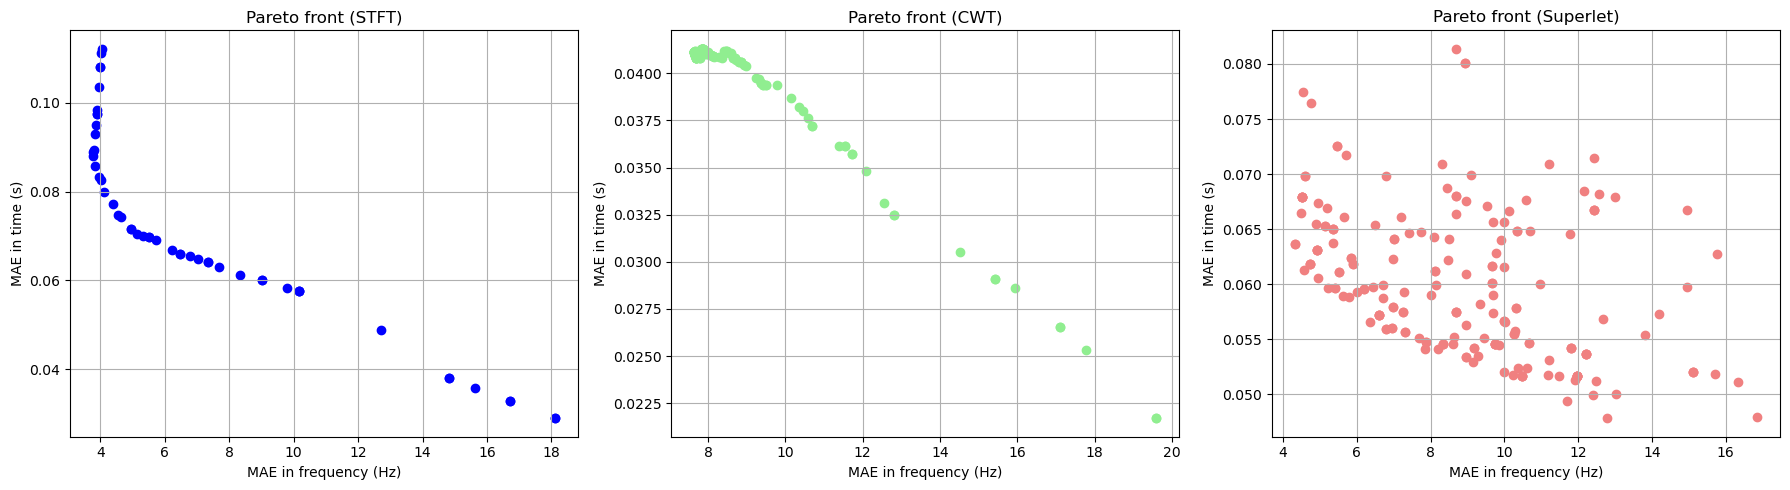

In [130]:
import matplotlib.pyplot as plt

# Calcula los límites a partir de los datos de Superlet
# x_min = min(mae_f_vals_superlet)
# x_max = max(mae_f_vals_superlet)
# y_min = min(mae_t_vals_superlet)
# y_max = max(mae_t_vals_superlet)
# 
# # Agrega márgenes
# x_margin = (x_max - x_min) * 0.05
# y_margin = (y_max - y_min) * 0.05
# xlim = (x_min - x_margin, x_max + x_margin)
# ylim = (y_min - y_margin, y_max + y_margin)

# Crear figura con 3 subplots en una fila
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Superlet
axs[0].scatter(mae_f_vals_stft, mae_t_vals_stft, c='blue')
axs[0].set_title("Pareto front (STFT)")
axs[0].set_xlabel("MAE in frequency (Hz)")
axs[0].set_ylabel("MAE in time (s)")
# axs[0].set_xlim(xlim)
# axs[0].set_ylim(ylim)
# axs[0].set_xlim(0,30)
# axs[0].set_ylim(0,0.16)
axs[0].grid(True)

# Wavelet
axs[1].scatter(mae_f_vals_our_wavelet, mae_t_vals_our_wavelet, c='lightgreen')
axs[1].set_title("Pareto front (CWT)")
axs[1].set_xlabel("MAE in frequency (Hz)")
axs[1].set_ylabel("MAE in time (s)")
# axs[1].set_xlim(0,30)
# axs[1].set_ylim(0,0.16)
axs[1].grid(True)

# STFT
axs[2].scatter(mae_f_vals_superlet, mae_t_vals_superlet, c='lightcoral')
axs[2].set_title("Pareto front (Superlet)")
axs[2].set_xlabel("MAE in frequency (Hz)")
axs[2].set_ylabel("MAE in time (s)")
# axs[2].set_xlim(0,30)
# axs[2].set_ylim(0,0.16)
# axs[2].set_ylim(ylim)
axs[2].grid(True)

# Ajustar espacio
plt.tight_layout()
plt.show()


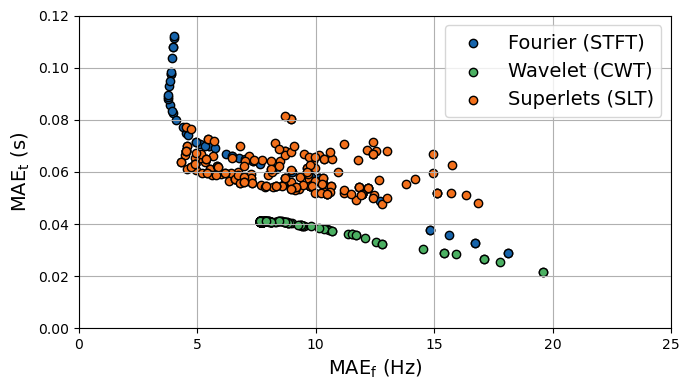

In [134]:
# Asumiendo que ya tienes los resultados de cada uno:
# listas de tuplas/lists: (mae_f, mae_t) para cada trial exitoso

colores_base = {                                 
    "STFT": plt.colormaps["Blues"],              
    "Wavelet": plt.colormaps["Greens"],          
    "Superlet": plt.colormaps["Oranges"],        
}        

wavelet_vals = [
    (trial.values[0], trial.values[1]) 
    for trial in study_our_cwt.trials 
    if trial.values is not None
]
stft_vals = [
    (trial.values[0], trial.values[1]) 
    for trial in study_stft.trials 
    if trial.values is not None
]

superlet_vals = [
    (trial.values[0], trial.values[1]) 
    for trial in study_superlet.trials 
    if trial.values is not None
]

# Separar coordenadas
stft_f, stft_t = zip(*stft_vals)
wavelet_f, wavelet_t = zip(*wavelet_vals)
superlet_f, superlet_t = zip(*superlet_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.scatter(stft_f, stft_t, color=colores_base["STFT"](0.8), label='Fourier (STFT)', edgecolor='black')
plt.scatter(wavelet_f, wavelet_t, color=colores_base["Wavelet"](0.6), label='Wavelet (CWT)', edgecolor='black')
plt.scatter(superlet_f, superlet_t, color=colores_base["Superlet"](0.6), label='Superlets (SLT)', edgecolor='black')

plt.xticks(np.arange(0, 26, 5))
plt.yticks(np.arange(0, 0.13, 0.02))

plt.ylim(0,0.12)
plt.xlim(0,25)

plt.xlabel("$\mathregular{MAE_f}$ (Hz)", fontsize=fontsize_labels)
plt.ylabel("$\mathregular{MAE_t}$ (s)", fontsize=fontsize_labels)
# plt.title("Pareto front (all values)", fontsize=fontsize_title)
plt.grid(True)
plt.legend(fontsize=fontsize_legend)
plt.tight_layout()
plt.show()


In [73]:
def get_pareto_vals(study):
    return [
        (trial.values[0], trial.values[1])
        for trial in study.best_trials
        if trial.values is not None
    ]

# Extraer solo los mejores
stft_vals = get_pareto_vals(study_stft)
wavelet_vals = get_pareto_vals(study_our_cwt)
superlet_vals = get_pareto_vals(study_superlet)

# Separar coordenadas (con seguridad)
stft_f, stft_t = zip(*stft_vals) if stft_vals else ([], [])
wavelet_f, wavelet_t = zip(*wavelet_vals) if wavelet_vals else ([], [])
superlet_f, superlet_t = zip(*superlet_vals) if superlet_vals else ([], [])


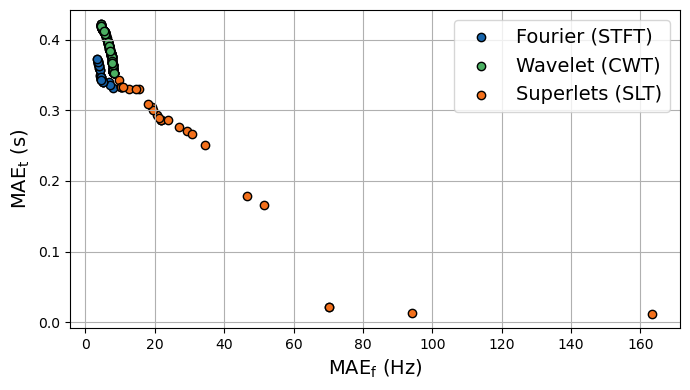

In [75]:
plt.figure(figsize=(7, 4))

plt.scatter(
    stft_f, stft_t,
    color=colores_base["STFT"](0.8),
    label='Fourier (STFT)',
    edgecolor='black'
)

plt.scatter(
    wavelet_f, wavelet_t,
    color=colores_base["Wavelet"](0.6),
    label='Wavelet (CWT)',
    edgecolor='black'
)

plt.scatter(
    superlet_f, superlet_t,
    color=colores_base["Superlet"](0.6),
    label='Superlets (SLT)',
    edgecolor='black'
)

# plt.xticks(np.arange(0, 36, 5))
# plt.yticks(np.arange(0, 0.17, 0.02))
# 
# plt.ylim(0, 0.16)
# plt.xlim(0, 35)

plt.xlabel(r"$\mathregular{MAE_f}$ (Hz)", fontsize=fontsize_labels)
plt.ylabel(r"$\mathregular{MAE_t}$ (s)", fontsize=fontsize_labels)

plt.grid(True)
plt.legend(fontsize=fontsize_legend)
plt.tight_layout()
plt.show()
